# Outliers: Detecção e Tratamento
## Notebook de estudo — versão comentada e corrigida

Este notebook segue a **mesma estrutura do original** (o que são → por que tratar →
quando importam → como detectar → como tratar), com o mesmo estilo de código
explícito: cada fórmula aparece escrita, sem função escondendo a conta.

O que foi acrescentado, e por quê:

| Acréscimo | Motivo pedagógico |
|---|---|
| Demonstração numérica do estrago que 1 outlier causa (seção 2) | "distorce estatísticas" vira número, não afirmação |
| Regra de ouro: outlier ≠ erro (seção 4) | o original dizia isso no texto e fazia o contrário no código |
| Anatomia do boxplot (seção 6) | o boxplot já **é** o método IQR desenhado — ligar as duas coisas |
| Demonstração do **mascaramento** do Z-score (7.2) | ensinar o método sem sua principal falha é ensinar pela metade |
| MAD / Z-score modificado (7.3) | o conserto do problema acima |
| Comparação lado a lado dos 3 métodos (7.5) e escolha do `k` (7.6) | 1.5 e 3 são convenções, não constantes |
| Isolation Forest, LOF e DBSCAN implementados (seção 8) | o original prometeu no markdown e não entregou |
| Passo "investigar antes de tratar" (seção 9) | é o passo que separa análise de gambiarra |
| Antes/depois em **todo** tratamento (seção 10) | comparar é o que ensina |
| Demonstração do estrago da imputação (10.3) | estava listada como se fosse só mais uma opção |
| Skew medido depois da transformação (10.4) | o original aplicou `log` e não conferiu |
| Sinalizar (flag) como 5ª opção (10.5) | quase sempre é a melhor, e faltava na lista |
| Vazamento de dados em contexto de ML (seção 11) | o título do original dizia "for ML" |
| Exercícios (seção 12) | fixar |

**Pré-requisito:** `pandas`, `numpy`, `scipy`, `seaborn`, `matplotlib`, `scikit-learn`.

## 1. O que são outliers?

Valores distantes da maior parte das outras observações.

Num conjunto de salários de uma empresa, o salário do CEO provavelmente é um outlier
— e, ainda assim, é um dado **válido e importante**. Guarde essa frase: ela é o
assunto da seção 4 e a razão de metade dos erros que se comete com outliers.

Outliers aparecem por três motivos bem diferentes, que exigem tratamentos diferentes:

| Origem | Exemplo | O que fazer |
|---|---|---|
| **Erro de medição/digitação** | altura de 17,8 cm; peso de 780 kg | corrigir ou remover |
| **Amostragem** — a linha pertence a outra população | um atacadista na base de varejo | separar, não misturar |
| **Variabilidade real** | o CEO; a compra de Natal; o atleta de 2,05 m | **manter** |

Só o primeiro caso justifica remoção sem discussão. Os outros dois são informação.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 110)
warnings.filterwarnings("ignore")

SEED = 42

## 2. Por que tratar outliers?

O original listava três motivos. Vamos **medir** cada um, porque ver o número
convence mais que ler a afirmação.

### 2.1 Distorção das medidas estatísticas

Nove salários normais e um do CEO:

In [2]:
salarios = np.array([3000, 3200, 3100, 3500, 2900, 3300, 3400, 3050, 3250])
salarios_com_ceo = np.append(salarios, 90000)

comparacao = pd.DataFrame({
    "sem o CEO": [salarios.mean(), np.median(salarios), salarios.std(ddof=1)],
    "com o CEO": [salarios_com_ceo.mean(), np.median(salarios_com_ceo),
                  salarios_com_ceo.std(ddof=1)],
}, index=["média", "mediana", "desvio padrão"]).round(1)
comparacao["variação %"] = ((comparacao["com o CEO"] / comparacao["sem o CEO"] - 1) * 100).round(1)
comparacao

,sem o CEO,com o CEO,variação %
média,3188.9,11870.0,272.2
mediana,3200.0,3225.0,0.8
desvio padrão,194.9,27452.7,13985.5


**Um único ponto** em dez multiplicou a média por ~3,8 e o desvio padrão por ~30.
A mediana praticamente não se moveu — por isso ela é chamada de estatística
**robusta**, e por isso os métodos baseados em mediana (seção 7.3) resistem a
outliers enquanto os baseados em média não.

Guarde a intuição: **média e desvio padrão são frágeis; mediana e quartis são robustos.**

### 2.2 Impacto em modelos de Machine Learning

Regressão linear minimiza o erro **ao quadrado** — então um ponto 10× mais distante
pesa 100× mais na conta. Um outlier consegue girar a reta inteira:

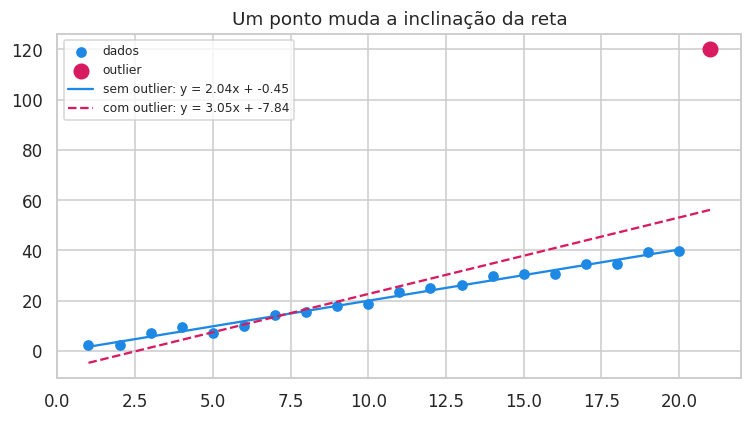

inclinação real ≈ 2.00 | estimada sem o outlier: 2.04 | com o outlier: 3.05


In [3]:
rng = np.random.default_rng(SEED)
x = np.arange(1, 21, dtype=float)
y = 2 * x + rng.normal(0, 1.5, 20)

x_out = np.append(x, 21.0)
y_out = np.append(y, 120.0)          # um único ponto fora da curva

coef_limpo = np.polyfit(x, y, 1)
coef_sujo = np.polyfit(x_out, y_out, 1)

plt.figure(figsize=(7, 4))
plt.scatter(x, y, label="dados", color="#1e88e5")
plt.scatter(21, 120, color="#d81b60", s=90, zorder=5, label="outlier")
plt.plot(x, np.polyval(coef_limpo, x), color="#1e88e5",
         label=f"sem outlier: y = {coef_limpo[0]:.2f}x + {coef_limpo[1]:.2f}")
plt.plot(x_out, np.polyval(coef_sujo, x_out), "--", color="#d81b60",
         label=f"com outlier: y = {coef_sujo[0]:.2f}x + {coef_sujo[1]:.2f}")
plt.legend(fontsize=8); plt.title("Um ponto muda a inclinação da reta")
plt.tight_layout(); plt.show()

print(f"inclinação real ≈ 2.00 | estimada sem o outlier: {coef_limpo[0]:.2f} "
      f"| com o outlier: {coef_sujo[0]:.2f}")

**Quais modelos sofrem, e quais não:**

| Sofrem muito | Praticamente indiferentes |
|---|---|
| Regressão linear/logística, k-means, PCA, kNN, redes neurais | Árvore de decisão, Random Forest, Gradient Boosting |
| Métricas com média: MSE, RMSE, R² | Métricas com mediana/absoluto: MAE, MedAE |

Isso já responde a pergunta "preciso tratar?": **depende do modelo**. Se você vai
usar Random Forest, provavelmente não precisa fazer nada.

### 2.3 Conclusões e decisões enganosas

"O ticket médio subiu 40%" pode significar que um cliente fez uma compra gigante.
Sempre que reportar média, olhe também a mediana — se as duas divergem muito, a
média não representa o caso típico.

## 3. Quando os outliers são exatamente o que você procura

Em algumas aplicações, o outlier **é** o objetivo. Remover é destruir o dado que importa:

1. **Detecção de anomalias** — em dados médicos, um valor extremo pode ser uma doença rara
2. **Detecção de fraude** — a transação atípica é a fraude
3. **Intrusão em rede** — o tráfego anômalo é o ataque
4. **Manutenção preditiva** — a vibração fora do padrão é a falha chegando
5. **Controle de qualidade** — a peça fora de especificação é o defeito

Nesses casos você inverte o pipeline: em vez de remover o que foi marcado, você
**investiga** o que foi marcado. As técnicas de detecção são as mesmas — muda o que
se faz com o resultado.

## 4. A regra de ouro: outlier ≠ erro

> **Detectar é estatística. Decidir é negócio.**

O fluxo correto tem **três** passos, e o passo do meio é o mais esquecido:

```
  [1] DETECTAR          [2] INVESTIGAR              [3] DECIDIR
  z-score / IQR  →   é impossível?  → sim →  erro: corrigir ou remover
  Isolation F.       é implausível? → talvez → separar / marcar
                     é só raro?     → sim  →  MANTER (é informação)
```

Pular o passo 2 é o erro mais caro do assunto. Quem pula:

- apaga o cliente enterprise da base de vendas (era o que pagava a conta)
- apaga a fraude do dataset de fraude
- remove os dias de pico e depois dimensiona a infraestrutura para o dia médio

**Teste prático antes de remover qualquer linha:** consigo explicar, em uma frase,
*por que este valor não deveria existir*? Se a resposta é só "porque está longe da
média", não remova — no máximo sinalize.

## 5. Preparação dos dados

Mesmo dataset do notebook original: medidas antropométricas do NHANES
(peso, altura e IMC de adultos nos EUA).

In [4]:
CAMINHO = "NHANES Weight and Height.csv"


def gerar_dados_exemplo(n=8388, seed=SEED):
    """Gera dados SINTÉTICOS parecidos com o NHANES, caso o CSV não esteja na pasta.

    Serve só para o notebook rodar do começo ao fim. Coloque o CSV real na mesma
    pasta e execute tudo de novo para trabalhar com os dados verdadeiros.
    """
    r = np.random.default_rng(seed)
    homem = r.random(n) < 0.49
    altura = np.where(homem, r.normal(175.5, 7.4, n), r.normal(161.8, 7.1, n))
    imc = np.exp(r.normal(np.log(27.2), 0.215, n))       # IMC é assimétrico à direita
    peso = imc * (altura / 100) ** 2

    altura, peso = np.round(altura, 1), np.round(peso, 1)
    imc_registrado = np.round(peso / (altura / 100) ** 2, 1)

    # alguns erros de digitação, para a seção 9 ter o que investigar.
    # de propósito são poucos e discretos: erros gigantes distorceriam o skew e
    # atrapalhariam as seções 6 e 7, que precisam da forma real da distribuição.
    idx = r.choice(n, 12, replace=False)
    altura[idx[:4]] = np.round(altura[idx[:4]] / 2.54, 1)  # cm gravado em polegada
    peso[idx[4:]] = np.round(peso[idx[4:]] + 27, 1)        # dígitos trocados

    return pd.DataFrame({"Unnamed: 0": np.arange(n), "Weight (kg)": peso,
                         "Standing Height (cm)": altura, "BMI(kg/m**2)": imc_registrado})


try:
    df = pd.read_csv(CAMINHO)
    print(f"Dados carregados de: {CAMINHO}")
except FileNotFoundError:
    df = gerar_dados_exemplo()
    print("CSV não encontrado — usando DADOS SINTÉTICOS de exemplo.")

df.head()

CSV não encontrado — usando DADOS SINTÉTICOS de exemplo.


,Unnamed: 0,Weight (kg),Standing Height (cm),BMI(kg/m**2)
0,0,83.6,167.0,30.0
1,1,103.8,180.4,31.9
2,2,43.1,154.5,18.1
3,3,52.3,156.5,21.4
4,4,108.5,188.1,30.7


In [5]:
df.shape

(8388, 4)

In [6]:
# a primeira coluna é só o índice exportado do arquivo original — não é uma variável
df = df.drop(columns=["Unnamed: 0"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8388 entries, 0 to 8387
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Weight (kg)           8388 non-null   float64
 1   Standing Height (cm)  8388 non-null   float64
 2   BMI(kg/m**2)          8388 non-null   float64
dtypes: float64(3)
memory usage: 196.7 KB


In [7]:
df.describe().round(2)

,Weight (kg),Standing Height (cm),BMI(kg/m**2)
count,8388.00,8388.00,8388.00
mean,79.76,168.67,27.91
std,20.04,10.15,6.13
min,28.10,59.30,10.90
25%,65.40,161.50,23.50
50%,77.40,168.50,27.30
75%,91.72,175.60,31.60
max,186.20,199.40,60.10


Já dá para desconfiar de algo pelo `describe()`: compare `mean` com `50%` (mediana)
e olhe `min` e `max` de cada coluna. Quando a média é bem maior que a mediana,
há cauda longa à direita. Quando `max` é absurdo, há erro de dado.

In [8]:
print("valores nulos por coluna:")
print(df.isna().sum())

valores nulos por coluna:
Weight (kg)             0
Standing Height (cm)    0
BMI(kg/m**2)            0
dtype: int64


**Por que checar nulos antes:** comparação com `NaN` sempre devolve `False`. Num
filtro do tipo `df[df["peso"] > limite]`, toda linha nula é silenciosamente
considerada "não outlier" e passa batido. Aqui não há nulos, mas na sua base
provavelmente haverá.

---
# Parte I — Como DETECTAR outliers

1. Métodos gráficos — boxplot, histograma, scatterplot
2. Métodos estatísticos — Z-score, Z-score modificado (MAD), IQR
3. Machine Learning — Isolation Forest, LOF, DBSCAN

## 6. Métodos gráficos

Sempre comece por aqui. O gráfico mostra **a forma** da distribuição, e a forma é
que decide qual método estatístico usar na seção seguinte.

### 6.1 Boxplot

Antes de olhar o gráfico, entenda o que ele desenha — porque o boxplot **já é o
método IQR** (seção 7.4) em forma visual:

```
        Q1        mediana      Q3
         │           │          │
  |------[===========|==========]------|      ● ●  ← pontos plotados = outliers
  │                                    │
  Q1 - 1,5×IQR                Q3 + 1,5×IQR      (as "hastes"/whiskers)
```

- A **caixa** vai de Q1 a Q3 e contém os 50% centrais dos dados (isso é o IQR)
- A **linha** dentro da caixa é a mediana, não a média
- As **hastes** vão até o valor mais extremo que ainda está dentro de 1,5×IQR
- Os **pontos soltos** são o que o matplotlib chama de outlier — pelo critério 1,5×IQR

Ou seja: quando você roda `sns.boxplot`, você já rodou o método IQR. A seção 7.4
só coloca número no que o gráfico mostrou.

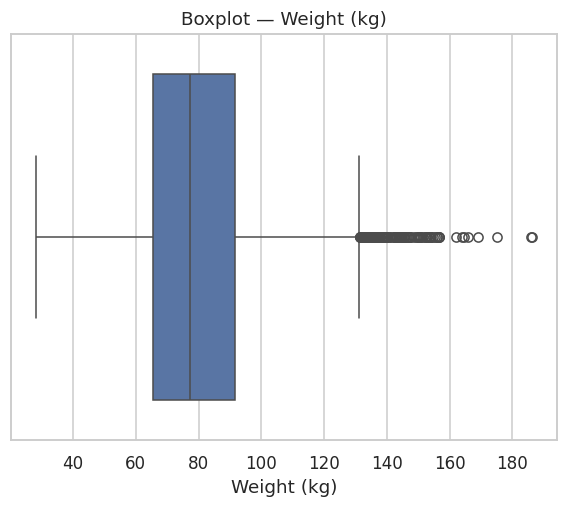

In [9]:
sns.boxplot(data=df, x="Weight (kg)")
plt.title("Boxplot — Weight (kg)")
plt.show()

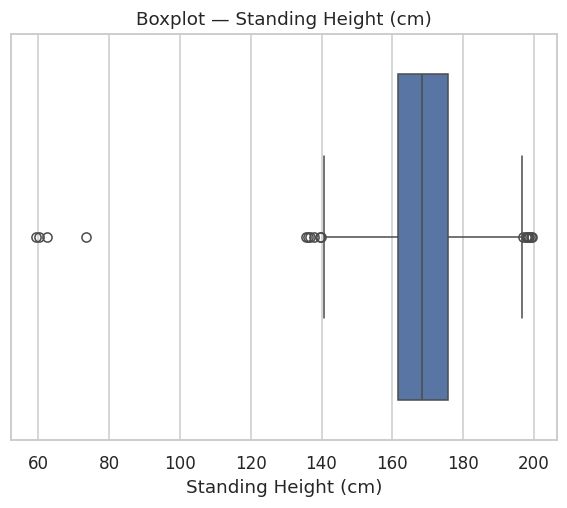

In [10]:
sns.boxplot(data=df, x="Standing Height (cm)")
plt.title("Boxplot — Standing Height (cm)")
plt.show()

Repare na diferença entre os dois: no peso os pontos aparecem **só à direita**
(cauda longa para cima — muita gente pesada, ninguém com peso negativo); na altura
eles aparecem **dos dois lados** (distribuição mais simétrica). Essa observação
visual é o que vai definir o método na seção 7.

### 6.2 Histograma

O boxplot resume; o histograma mostra a forma inteira, inclusive se há dois picos
(o que indicaria mistura de populações — homens e mulheres, por exemplo).

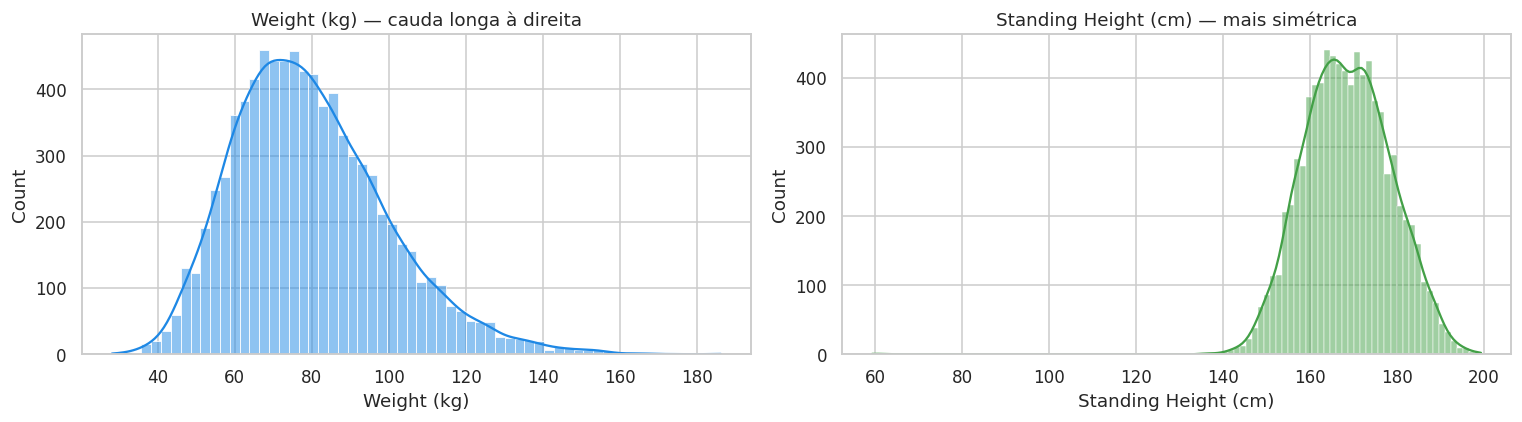

In [11]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
sns.histplot(df["Weight (kg)"], kde=True, color="#1e88e5")
plt.title("Weight (kg) — cauda longa à direita")

plt.subplot(1, 2, 2)
sns.histplot(df["Standing Height (cm)"], kde=True, color="#43a047")
plt.title("Standing Height (cm) — mais simétrica")

plt.tight_layout()
plt.show()

### 6.3 Scatterplot — outliers *bivariados*

Este é o gráfico mais subestimado do assunto. Existem pontos que são **normais em
cada variável isolada** e absurdos na combinação — e nenhum método univariado
(seção 7) consegue enxergá-los.

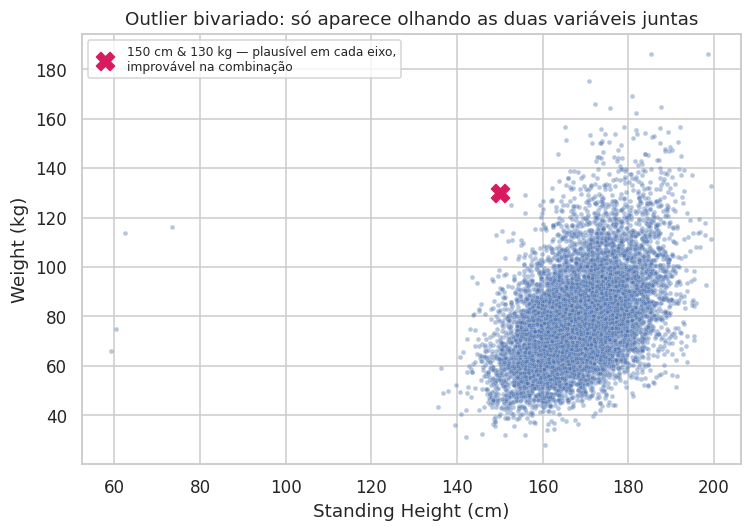

In [12]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Standing Height (cm)", y="Weight (kg)", s=10, alpha=0.4)

# ponto ilustrativo: 1,50 m e 130 kg. Cada valor, isolado, é plausível.
plt.scatter([150], [130], color="#d81b60", s=140, marker="X", zorder=5,
            label="150 cm & 130 kg — plausível em cada eixo,\nimprovável na combinação")
plt.legend(fontsize=8, loc="upper left")
plt.title("Outlier bivariado: só aparece olhando as duas variáveis juntas")
plt.tight_layout()
plt.show()

Guarde: **outlier univariado ≠ outlier multivariado.** A seção 8 resolve o caso
multivariado de forma automática.

## 7. Métodos estatísticos

### 7.1 Primeiro decida: a distribuição é simétrica ou assimétrica?

A escolha do método não é gosto pessoal, é consequência da forma dos dados:

| Forma | Método | Por quê |
|---|---|---|
| Simétrica, parecida com normal (\|skew\| < 0,5) | **Z-score** | pressupõe simetria em torno da média |
| Assimétrica (\|skew\| ≥ 0,5) | **IQR** | usa quartis, não pressupõe simetria |
| Suspeita de outlier extremo puxando as contas | **MAD** | robusto por construção |

Duas ferramentas para decidir: o coeficiente de assimetria (skew) e o QQ-plot.

In [13]:
df.skew().round(3)

Weight (kg)             0.719
Standing Height (cm)   -0.445
BMI(kg/m**2)            0.666
dtype: float64

**Como ler o skew:** 0 = simétrica; positivo = cauda à direita; negativo = cauda à
esquerda. Na prática: |skew| < 0,5 ≈ simétrica; entre 0,5 e 1 ≈ moderada; > 1 ≈ forte.

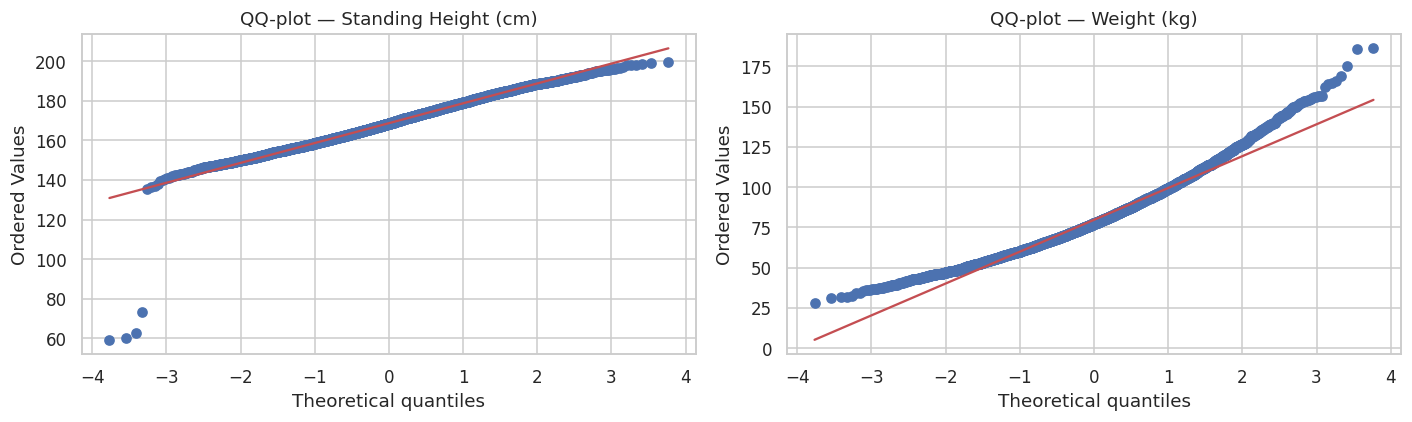

In [14]:
plt.figure(figsize=(13, 4))

plt.subplot(1, 2, 1)
stats.probplot(df["Standing Height (cm)"], dist="norm", plot=plt)
plt.title("QQ-plot — Standing Height (cm)")

plt.subplot(1, 2, 2)
stats.probplot(df["Weight (kg)"], dist="norm", plot=plt)
plt.title("QQ-plot — Weight (kg)")

plt.tight_layout()
plt.show()

**Como ler o QQ-plot:** cada ponto compara um quantil dos seus dados com o quantil
correspondente de uma normal. Se os dados fossem normais, todos os pontos cairiam
sobre a reta vermelha. Pontos que **sobem** acima da reta na ponta direita indicam
cauda longa à direita. É exatamente o que se vê no peso e não se vê na altura.

### 7.2 Z-score

**Quantos desvios padrão o ponto está afastado da média.**

$$z = \frac{x - \mu}{\sigma} \qquad\Longleftrightarrow\qquad x = \mu + z\sigma$$

Convenção: |z| > 3 é candidato a outlier. De onde vem o 3? Numa distribuição normal:

| Faixa | % dos dados dentro |
|---|---|
| μ ± 1σ | 68,3% |
| μ ± 2σ | 95,4% |
| μ ± 3σ | **99,7%** |

Então ±3σ deixa de fora ~0,3% dos pontos **por puro acaso**. Com 8.388 linhas, isso
são ~22 pontos esperados mesmo sem nenhuma anomalia real. Esse número é sua régua:
se achou muito menos, sua cauda é mais leve que a normal; muito mais, é mais pesada.

Vamos aplicar na altura, que é a coluna aproximadamente simétrica.

In [15]:
zscore_altura = stats.zscore(df["Standing Height (cm)"])
zscore_altura[:5]

array([-0.16414692,  1.15557544, -1.39523121, -1.19825772,  1.91392336])

In [16]:
df1 = df.copy()
df1["Z Score Height"] = zscore_altura
df1.head()

,Weight (kg),Standing Height (cm),BMI(kg/m**2),Z Score Height
0,83.6,167.0,30.0,-0.164147
1,103.8,180.4,31.9,1.155575
2,43.1,154.5,18.1,-1.395231
3,52.3,156.5,21.4,-1.198258
4,108.5,188.1,30.7,1.913923


O Z-score é só uma **mudança de escala**: a forma da distribuição é idêntica, o que
muda é o eixo (agora centrado em 0, medido em desvios padrão).

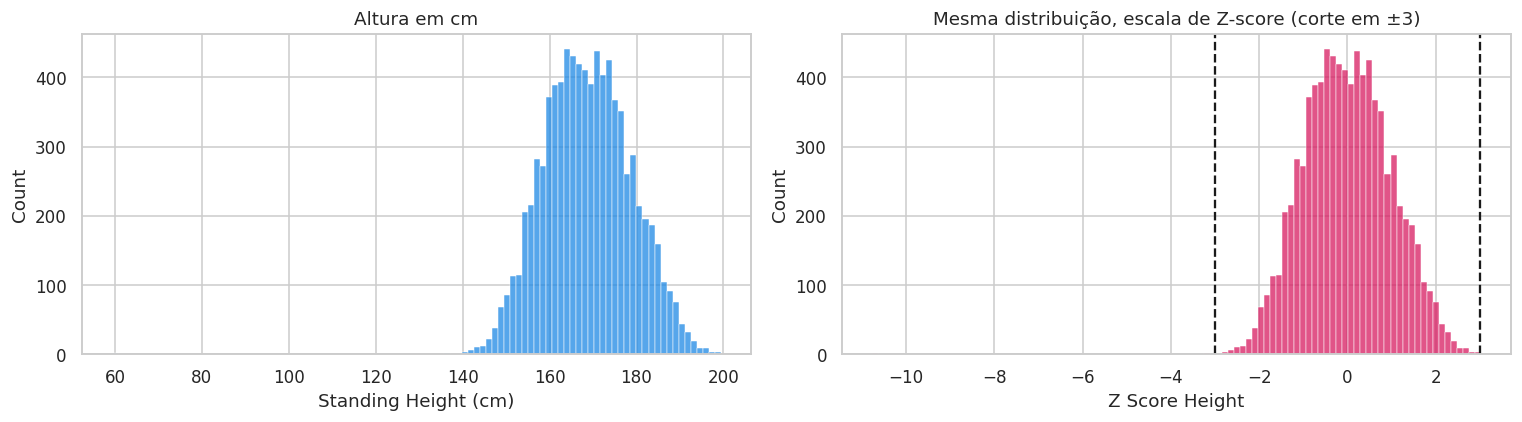

In [17]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
sns.histplot(df1["Standing Height (cm)"], color="#1e88e5")
plt.title("Altura em cm")

plt.subplot(1, 2, 2)
sns.histplot(df1["Z Score Height"], color="#d81b60")
plt.axvline(-3, color="k", ls="--"); plt.axvline(3, color="k", ls="--")
plt.title("Mesma distribuição, escala de Z-score (corte em ±3)")

plt.tight_layout()
plt.show()

In [18]:
mascara_z = (zscore_altura < -3) | (zscore_altura > 3)

print(f"outliers pelo Z-score: {mascara_z.sum()} de {len(df)} linhas "
      f"({mascara_z.mean() * 100:.2f}% da base)")
print(f"esperado por acaso numa normal: ~{0.0027 * len(df):.0f} pontos")
df1[mascara_z]

outliers pelo Z-score: 10 de 8388 linhas (0.12% da base)
esperado por acaso numa normal: ~23 pontos


,Weight (kg),Standing Height (cm),BMI(kg/m**2),Z Score Height
1055,74.8,60.3,31.9,-10.672682
1062,111.5,199.4,28.0,3.026824
2395,59.2,136.3,31.9,-3.187690
2555,50.0,137.8,26.3,-3.039960
2598,43.3,135.5,23.6,-3.266479
3235,116.2,73.5,33.3,-9.372657
4102,66.1,59.3,29.1,-10.771169
7040,113.8,62.5,45.2,-10.456012
7445,49.0,136.7,26.2,-3.148295
8146,132.9,199.2,33.5,3.007126


**Os mesmos limites, em centímetros.** Como $x = \mu + z\sigma$, basta isolar:

É este número que você leva para uma reunião — ninguém aprova regra em "z-score",
mas todo mundo entende "abaixo de 1,36 m ou acima de 1,97 m".

In [19]:
media = df["Standing Height (cm)"].mean()
desvio = df["Standing Height (cm)"].std()

x_inferior = media - 3 * desvio
x_superior = media + 3 * desvio

print(f"média = {media:.2f} cm | desvio padrão = {desvio:.2f} cm")
print(f"limite inferior = {x_inferior:.2f} cm")
print(f"limite superior = {x_superior:.2f} cm")

média = 168.67 cm | desvio padrão = 10.15 cm
limite inferior = 138.20 cm
limite superior = 199.13 cm


In [20]:
# confirma que dá exatamente o mesmo resultado do corte em ±3
df[(df["Standing Height (cm)"] < x_inferior) | (df["Standing Height (cm)"] > x_superior)]

,Weight (kg),Standing Height (cm),BMI(kg/m**2)
1055,74.8,60.3,31.9
1062,111.5,199.4,28.0
2395,59.2,136.3,31.9
2555,50.0,137.8,26.3
2598,43.3,135.5,23.6
3235,116.2,73.5,33.3
4102,66.1,59.3,29.1
7040,113.8,62.5,45.2
7445,49.0,136.7,26.2
8146,132.9,199.2,33.5


#### ⚠️ 7.2.1 A falha do Z-score: o mascaramento

Aqui está a parte que o notebook original não contava, e que faz o método falhar
justamente quando você mais precisa dele.

O Z-score usa **média** e **desvio padrão** — e nós acabamos de ver (seção 2.1) que
essas duas medidas são destruídas por outliers. Ou seja: **o outlier infla o próprio
limiar que deveria detectá-lo.** Isso se chama *masking* (mascaramento).

Veja com nove valores normais e um absurdo:

In [21]:
dados = np.array([10, 12, 11, 13, 12, 11, 12, 10, 13, 500], dtype=float)

media_d = dados.mean()
desvio_d = dados.std(ddof=1)
z = (dados - media_d) / desvio_d

print(f"média = {media_d:.1f} | desvio padrão = {desvio_d:.1f}")
print(f"limite superior (μ + 3σ) = {media_d + 3 * desvio_d:.1f}")
print()
print(pd.DataFrame({"valor": dados, "z-score": z.round(2),
                    "é outlier? (|z|>3)": np.abs(z) > 3}).to_string(index=False))

média = 60.4 | desvio padrão = 154.5
limite superior (μ + 3σ) = 523.8

 valor  z-score  é outlier? (|z|>3)
  10.0    -0.33               False
  12.0    -0.31               False
  11.0    -0.32               False
  13.0    -0.31               False
  12.0    -0.31               False
  11.0    -0.32               False
  12.0    -0.31               False
  10.0    -0.33               False
  13.0    -0.31               False
 500.0     2.85               False


**O 500 não foi detectado.** Ele puxou a média para 60,4 e o desvio para ~154, então
o limiar virou ~522 — maior que o próprio outlier. O método foi cego pelo dado que
deveria encontrar.

Quando isso acontece na prática:

- amostras pequenas (< 100 linhas)
- poucos outliers, mas muito extremos
- vários outliers juntos (aí eles se protegem mutuamente)

A solução é trocar média e desvio por medidas robustas → é a próxima seção.

### 7.3 Z-score modificado (MAD) — a versão robusta

Mesma ideia do Z-score, trocando as peças frágeis pelas robustas:

| | Z-score clássico | Z-score modificado |
|---|---|---|
| centro | média | **mediana** |
| dispersão | desvio padrão | **MAD** = mediana(\|x − mediana\|) |
| corte usual | 3 | **3,5** |

$$z_{mod} = \frac{0{,}6745\,(x - \tilde{x})}{MAD}$$

O fator 0,6745 existe só para deixar o MAD comparável ao desvio padrão de uma
normal (assim o corte 3,5 fica na mesma ordem de grandeza do 3 do método clássico).

Rodando no mesmo exemplo que falhou:

In [22]:
mediana_d = np.median(dados)
mad = np.median(np.abs(dados - mediana_d))
z_mod = 0.6745 * (dados - mediana_d) / mad

print(f"mediana = {mediana_d:.1f} | MAD = {mad:.1f}")
print()
print(pd.DataFrame({"valor": dados, "z clássico": z.round(2),
                    "z modificado": z_mod.round(2),
                    "detectado? (|z_mod|>3,5)": np.abs(z_mod) > 3.5}).to_string(index=False))

mediana = 12.0 | MAD = 1.0

 valor  z clássico  z modificado  detectado? (|z_mod|>3,5)
  10.0       -0.33         -1.35                     False
  12.0       -0.31          0.00                     False
  11.0       -0.32         -0.67                     False
  13.0       -0.31          0.67                     False
  12.0       -0.31          0.00                     False
  11.0       -0.32         -0.67                     False
  12.0       -0.31          0.00                     False
  10.0       -0.33         -1.35                     False
  13.0       -0.31          0.67                     False
 500.0        2.85        329.16                      True


Agora sim: z modificado ≈ 329 para o valor 500. A mediana e o MAD nem perceberam a
presença do outlier, então o limiar continuou honesto.

**Regra prática:** na dúvida, use o Z-score modificado. Ele não é pior que o clássico
em nenhum cenário — só é menos conhecido.

Aplicando na altura do dataset real:

In [23]:
coluna = "Standing Height (cm)"

mediana_altura = df[coluna].median()
mad_altura = stats.median_abs_deviation(df[coluna])        # sem escala
z_mod_altura = 0.6745 * (df[coluna] - mediana_altura) / mad_altura
mascara_mad = z_mod_altura.abs() > 3.5

print(f"mediana = {mediana_altura:.2f} cm | MAD = {mad_altura:.2f}")
print(f"limite inferior = {mediana_altura - 3.5 * mad_altura / 0.6745:.2f} cm")
print(f"limite superior = {mediana_altura + 3.5 * mad_altura / 0.6745:.2f} cm")
print(f"outliers pelo MAD: {mascara_mad.sum()} ({mascara_mad.mean() * 100:.2f}%)")

mediana = 168.50 cm | MAD = 7.00
limite inferior = 132.18 cm
limite superior = 204.82 cm
outliers pelo MAD: 4 (0.05%)


### 7.4 IQR (Interquartile Range) — para dados assimétricos

O procedimento, exatamente como no boxplot da seção 6.1:

1. **Calcular o IQR**: distância entre o terceiro quartil (Q3) e o primeiro (Q1)
2. **Determinar os limites**:
   - mínimo: `Q1 - 1,5 × IQR`
   - máximo: `Q3 + 1,5 × IQR`
3. **Identificar**: qualquer ponto abaixo do mínimo ou acima do máximo

Por que funciona melhor em dados assimétricos: quartis não pressupõem simetria.
Se a cauda direita é mais longa, Q3 se afasta mais da mediana do que Q1, e o limite
superior automaticamente fica mais distante que o inferior — o método se adapta
à forma dos dados, coisa que o ±3σ não faz.

Aplicando no peso, que é a coluna assimétrica (confira o skew impresso na seção 7.1):

In [24]:
q1 = df["Weight (kg)"].quantile(0.25)
q3 = df["Weight (kg)"].quantile(0.75)
iqr = q3 - q1

print(f"Q1 = {q1:.2f} kg")
print(f"Q3 = {q3:.2f} kg")
print(f"IQR = Q3 - Q1 = {iqr:.2f} kg")

Q1 = 65.40 kg
Q3 = 91.72 kg
IQR = Q3 - Q1 = 26.32 kg


In [25]:
minimo = q1 - 1.5 * iqr
maximo = q3 + 1.5 * iqr

print(f"limite inferior = Q1 - 1,5 × IQR = {minimo:.2f} kg")
print(f"limite superior = Q3 + 1,5 × IQR = {maximo:.2f} kg")

limite inferior = Q1 - 1,5 × IQR = 25.91 kg
limite superior = Q3 + 1,5 × IQR = 131.21 kg


In [26]:
mascara_iqr = (df["Weight (kg)"] < minimo) | (df["Weight (kg)"] > maximo)

print(f"outliers pelo IQR: {mascara_iqr.sum()} de {len(df)} linhas "
      f"({mascara_iqr.mean() * 100:.2f}% da base)")
print(f"  abaixo do limite inferior: {(df['Weight (kg)'] < minimo).sum()}")
print(f"  acima do limite superior: {(df['Weight (kg)'] > maximo).sum()}")

df[mascara_iqr].head(10)

outliers pelo IQR: 144 de 8388 linhas (1.72% da base)
  abaixo do limite inferior: 0
  acima do limite superior: 144


,Weight (kg),Standing Height (cm),BMI(kg/m**2)
32,139.8,179.4,35.0
146,133.0,187.6,37.8
160,147.5,177.6,46.8
192,148.7,189.7,41.3
209,132.5,166.4,47.9
254,186.1,185.4,54.1
267,150.0,173.4,49.9
338,144.4,173.1,48.2
362,133.7,189.0,37.4
376,136.1,172.7,45.6


Repare no desequilíbrio: praticamente todos os marcados estão **acima**. Isso é a
assinatura da assimetria à direita — e é a confirmação numérica do que o boxplot da
seção 6.1 já tinha mostrado.

**Sempre imprima a contagem e o percentual.** Se um método marca mais de ~5% da
base, ele não está achando anomalia: está descrevendo a distribuição. Nesse caso o
problema é o método ou o `k`, não os dados.

### 7.5 Os três métodos lado a lado

Mesma coluna, três critérios, três respostas diferentes. Não existe resposta "certa" —
existe critério declarado.

In [27]:
comparacao_metodos = []

for nome_col in ["Weight (kg)", "Standing Height (cm)"]:
    s = df[nome_col]

    # Z-score (k=3)
    lo_z, hi_z = s.mean() - 3 * s.std(), s.mean() + 3 * s.std()
    # MAD (k=3.5)
    mad_ = stats.median_abs_deviation(s, scale="normal")     # já inclui o 0,6745
    lo_m, hi_m = s.median() - 3.5 * mad_, s.median() + 3.5 * mad_
    # IQR (k=1.5)
    q1_, q3_ = s.quantile(0.25), s.quantile(0.75)
    lo_i, hi_i = q1_ - 1.5 * (q3_ - q1_), q3_ + 1.5 * (q3_ - q1_)

    for metodo, lo, hi in [("Z-score (k=3)", lo_z, hi_z),
                           ("MAD (k=3,5)", lo_m, hi_m),
                           ("IQR (k=1,5)", lo_i, hi_i)]:
        m = (s < lo) | (s > hi)
        comparacao_metodos.append({
            "coluna": nome_col, "método": metodo,
            "limite_inf": round(lo, 2), "limite_sup": round(hi, 2),
            "n_outliers": int(m.sum()), "%_da_base": round(m.mean() * 100, 2),
        })

pd.DataFrame(comparacao_metodos).set_index(["coluna", "método"])

limite_inf  limite_sup  n_outliers  %_da_base
coluna               método                                                      
Weight (kg)          Z-score (k=3)       19.63      139.88          61       0.73
                     MAD (k=3,5)          9.94      144.86          43       0.51
                     IQR (k=1,5)         25.91      131.21         144       1.72
Standing Height (cm) Z-score (k=3)      138.20      199.13          10       0.12
                     MAD (k=3,5)        132.18      204.82           4       0.05
                     IQR (k=1,5)        140.35      196.75          17       0.20

**O que aprender com a tabela:**

- Na coluna **assimétrica** (peso), o IQR marca bem mais que o Z-score. Não é erro:
  o Z-score, por ser simétrico, estica o limite superior para acomodar a cauda e
  acaba deixando passar valores que o IQR pega.
- Na coluna **simétrica** (altura), os três concordam bastante. Quando os métodos
  concordam, você tem pouca dúvida; quando divergem muito, a forma da distribuição
  está te avisando que a escolha do método importa.
- O número de outliers **não é uma propriedade dos dados** — é consequência do
  critério que você escolheu.

### 7.6 O `k` é uma escolha sua, não uma constante da natureza

`1,5` e `3` são convenções que funcionam bem em distribuições parecidas com a normal.
Em dados financeiros, de sensores ou de cliques — que têm cauda muito mais pesada —
`1,5 × IQR` pode marcar 15% da base. Antes de fixar um valor, veja a curva:

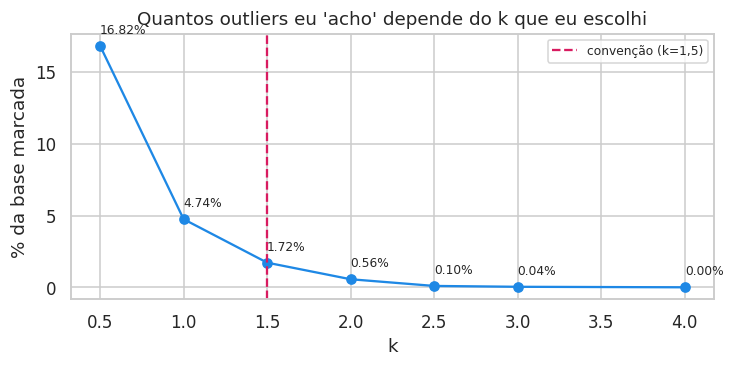

,k,%_marcado
0,0.5,16.82
1,1.0,4.74
2,1.5,1.72
3,2.0,0.56
4,2.5,0.10
5,3.0,0.04
6,4.0,0.00


In [28]:
valores_k = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0]
percentuais = []

for k in valores_k:
    lo = q1 - k * iqr
    hi = q3 + k * iqr
    m = (df["Weight (kg)"] < lo) | (df["Weight (kg)"] > hi)
    percentuais.append(m.mean() * 100)

plt.figure(figsize=(7, 3.5))
plt.plot(valores_k, percentuais, "o-", color="#1e88e5")
for kx, py in zip(valores_k, percentuais):
    plt.annotate(f"{py:.2f}%", (kx, py), textcoords="offset points", xytext=(0, 8), fontsize=8)
plt.axvline(1.5, color="#d81b60", ls="--", label="convenção (k=1,5)")
plt.xlabel("k"); plt.ylabel("% da base marcada")
plt.title("Quantos outliers eu 'acho' depende do k que eu escolhi")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

pd.DataFrame({"k": valores_k, "%_marcado": np.round(percentuais, 2)})

Um valor bastante usado além do 1,5 é o **3,0×IQR**, chamado de limite *far out* —
reserva o rótulo de outlier para os casos realmente extremos.

## 8. Machine Learning para detecção

Os métodos das seções anteriores olham **uma coluna por vez**. Isso tem dois limites:

1. não enxergam a combinação improvável (o caso 1,50 m / 130 kg da seção 6.3)
2. com muitas colunas, aplicar o teste em cada uma marca uma fração enorme da base
   por acúmulo (20 colunas a 1% cada ≈ 18% da base marcada em alguma coluna)

Os três algoritmos abaixo trabalham no espaço multivariado.

| Algoritmo | Ideia central | Quando usar |
|---|---|---|
| **Isolation Forest** | quantos cortes aleatórios são necessários para isolar o ponto — anômalo isola rápido | muitas colunas; sem suposição de forma |
| **LOF** | compara a densidade local do ponto com a dos vizinhos | grupos com densidades diferentes |
| **DBSCAN** | agrupa por densidade; o que sobra é ruído | quando você também quer os clusters |

**Padronize antes.** Todos os três usam distância, e peso (kg) e altura (cm) têm
escalas diferentes — sem padronizar, a variável de maior amplitude domina o cálculo.

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN

X = df[["Standing Height (cm)", "Weight (kg)"]]
X_padronizado = StandardScaler().fit_transform(X)

CONTAMINACAO = 0.01   # premissa explícita: espero ~1% de anomalias

print("antes de padronizar:")
print(X.describe().loc[["mean", "std"]].round(2))
print("\ndepois de padronizar (média 0, desvio 1):")
print(pd.DataFrame(X_padronizado, columns=X.columns).describe().loc[["mean", "std"]].round(2))

antes de padronizar:
      Standing Height (cm)  Weight (kg)
mean                168.67        79.76
std                  10.15        20.04

depois de padronizar (média 0, desvio 1):
      Standing Height (cm)  Weight (kg)
mean                  -0.0          0.0
std                    1.0          1.0


### 8.1 Isolation Forest

Constrói várias árvores com cortes aleatórios. Um ponto isolado no espaço é separado
dos demais com **poucos cortes**; um ponto no meio da massa precisa de muitos.
O score é a média de cortes necessários entre todas as árvores.

⚠️ O parâmetro `contamination` é **você** quem informa — o algoritmo não descobre
quantos outliers existem, ele devolve exatamente a fração que você pediu.

In [30]:
iso = IsolationForest(contamination=CONTAMINACAO, random_state=SEED, n_estimators=200)
rotulo_iso = iso.fit_predict(X_padronizado)      # -1 = outlier, 1 = normal

mascara_iso = rotulo_iso == -1
print(f"Isolation Forest marcou {mascara_iso.sum()} pontos ({mascara_iso.mean()*100:.2f}%)")

Isolation Forest marcou 84 pontos (1.00%)


### 8.2 Local Outlier Factor (LOF)

Compara a densidade em volta do ponto com a densidade em volta dos seus `k` vizinhos.
Se o ponto está numa região muito mais vazia que a de seus vizinhos, é anômalo.

A diferença prática para o Isolation Forest: o LOF é **local**. Ele consegue apontar
um ponto que está dentro da nuvem geral, mas numa "bolha" vazia dela.

In [31]:
lof = LocalOutlierFactor(n_neighbors=30, contamination=CONTAMINACAO)
rotulo_lof = lof.fit_predict(X_padronizado)

mascara_lof = rotulo_lof == -1
print(f"LOF marcou {mascara_lof.sum()} pontos ({mascara_lof.mean()*100:.2f}%)")

LOF marcou 84 pontos (1.00%)


### 8.3 DBSCAN

Agrupa pontos por densidade: quem tem pelo menos `min_samples` vizinhos dentro de um
raio `eps` forma cluster; quem sobra recebe o rótulo `-1` (ruído) — e é esse ruído
que interpretamos como outlier.

`eps` é sensível: muito pequeno e quase tudo vira ruído; muito grande e nada vira.
Como os dados estão padronizados, `eps` está em desvios padrão, o que facilita.

In [32]:
dbscan = DBSCAN(eps=0.5, min_samples=15)
rotulo_db = dbscan.fit_predict(X_padronizado)

mascara_db = rotulo_db == -1
print(f"clusters encontrados: {len(set(rotulo_db)) - (1 if -1 in rotulo_db else 0)}")
print(f"DBSCAN marcou {mascara_db.sum()} pontos como ruído ({mascara_db.mean()*100:.2f}%)")

clusters encontrados: 1
DBSCAN marcou 20 pontos como ruído (0.24%)


### 8.4 Comparando visualmente com o método univariado

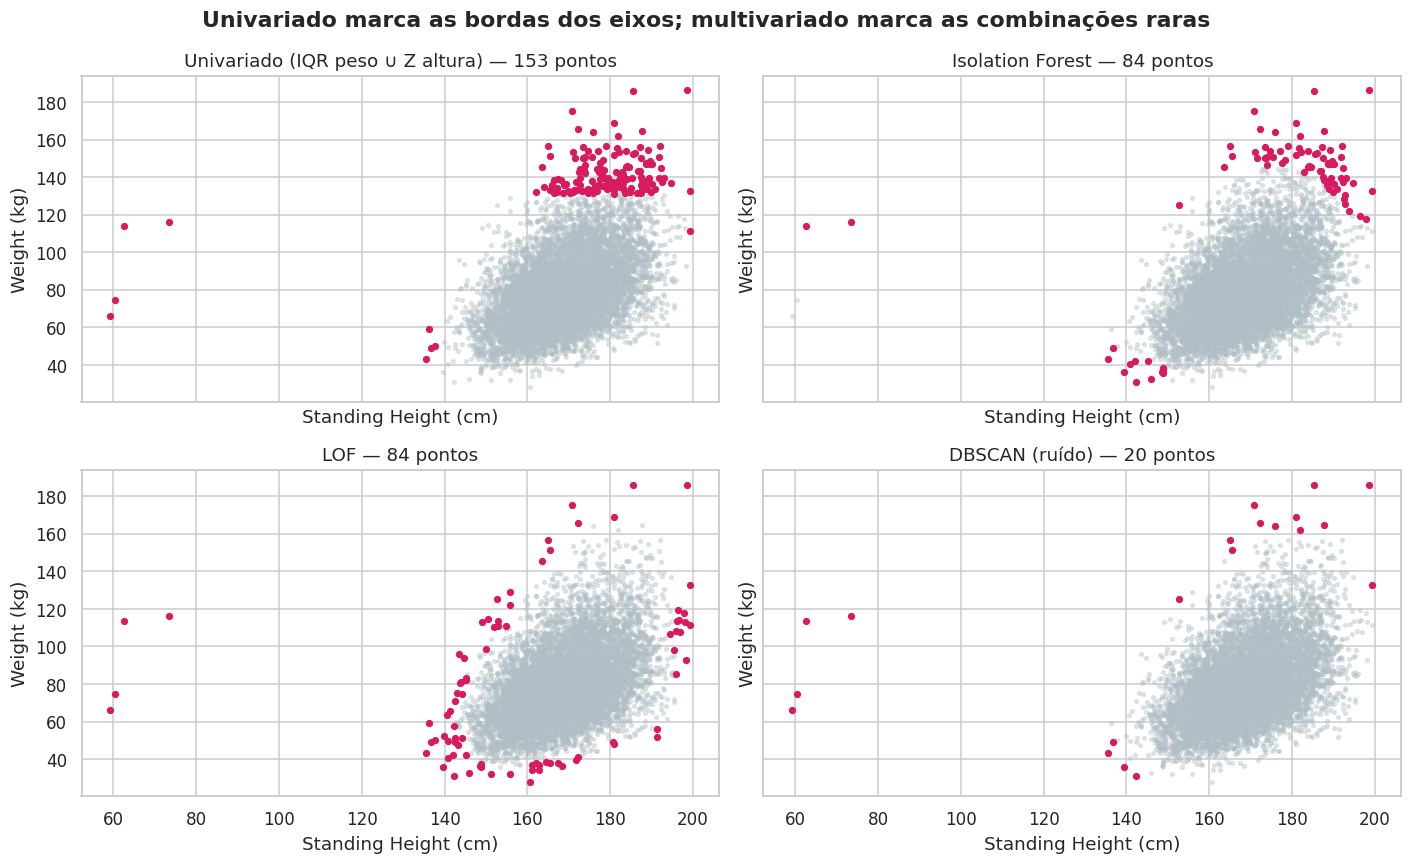

In [33]:
mascara_univariada = mascara_iqr | pd.Series(mascara_z, index=df.index)

todas = {
    "Univariado (IQR peso ∪ Z altura)": mascara_univariada.to_numpy(),
    "Isolation Forest": mascara_iso,
    "LOF": mascara_lof,
    "DBSCAN (ruído)": mascara_db,
}

fig, eixos = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey=True)
for eixo, (nome, m) in zip(eixos.ravel(), todas.items()):
    eixo.scatter(df.loc[~m, "Standing Height (cm)"], df.loc[~m, "Weight (kg)"],
                 s=6, alpha=0.35, color="#b0bec5")
    eixo.scatter(df.loc[m, "Standing Height (cm)"], df.loc[m, "Weight (kg)"],
                 s=14, color="#d81b60")
    eixo.set_title(f"{nome} — {m.sum()} pontos")
    eixo.set_xlabel("Standing Height (cm)"); eixo.set_ylabel("Weight (kg)")

fig.suptitle("Univariado marca as bordas dos eixos; multivariado marca as combinações raras",
             fontweight="bold")
plt.tight_layout()
plt.show()

Olhe os quatro painéis com atenção — é a lição central da seção:

- o **univariado** marca faixas retangulares (as bordas de cada eixo) e deixa passar
  os pontos estranhos do meio
- os **multivariados** marcam as bordas da *nuvem*, incluindo pontos que estão dentro
  da faixa normal de cada variável isolada

**Consenso é uma heurística barata:** um ponto marcado por três métodos independentes
é candidato forte; marcado por um só, costuma ser artefato da suposição daquele método.

In [34]:
tabela_consenso = pd.DataFrame(todas).astype(int)
tabela_consenso["quantos_metodos"] = tabela_consenso.sum(axis=1)

print("em quantos métodos cada linha foi marcada:")
print(tabela_consenso["quantos_metodos"].value_counts().sort_index().to_string())

em quantos métodos cada linha foi marcada:
quantos_metodos
0    8163
1     142
2      62
3       9
4      12


---
## 9. Antes de tratar: **investigar**

Detectamos. Agora vem o passo 2 do fluxo da seção 4 — e não o passo 3.

Três perguntas, nesta ordem:

### 9.1 O valor é fisicamente possível?

Isto não é estatística, é conhecimento de domínio. O adulto mais alto documentado
tinha 272 cm; o mais pesado, ~440 kg. Qualquer coisa fora disso é erro de registro,
e aí a remoção não precisa de defesa.

In [35]:
limites_plausiveis = {
    "Weight (kg)": (20, 350),
    "Standing Height (cm)": (100, 260),
    "BMI(kg/m**2)": (10, 100),
}

for coluna_, (lo_, hi_) in limites_plausiveis.items():
    fora = (df[coluna_] < lo_) | (df[coluna_] > hi_)
    print(f"{coluna_:24s} fora de [{lo_}, {hi_}]: {fora.sum()} linhas")

mascara_impossivel = pd.Series(False, index=df.index)
for coluna_, (lo_, hi_) in limites_plausiveis.items():
    mascara_impossivel |= (df[coluna_] < lo_) | (df[coluna_] > hi_)

df[mascara_impossivel]

Weight (kg)              fora de [20, 350]: 0 linhas
Standing Height (cm)     fora de [100, 260]: 4 linhas
BMI(kg/m**2)             fora de [10, 100]: 0 linhas


,Weight (kg),Standing Height (cm),BMI(kg/m**2)
1055,74.8,60.3,31.9
3235,116.2,73.5,33.3
4102,66.1,59.3,29.1
7040,113.8,62.5,45.2


### 9.2 A linha é internamente coerente?

O dataset tem três colunas ligadas por uma identidade: **IMC = peso / altura²**.
Se o IMC informado não bate com o recalculado, uma das três colunas está errada
*naquela linha* — e isso é um erro comprovado, não uma pessoa incomum.

Generalize a ideia para qualquer base: `receita = preço × quantidade`,
`total = soma das partes`, `data_fim ≥ data_início`. Essas checagens acham erro real
com precisão muito maior que qualquer limiar de cauda.

In [36]:
imc_recalculado = df["Weight (kg)"] / (df["Standing Height (cm)"] / 100) ** 2
erro_relativo = (imc_recalculado - df["BMI(kg/m**2)"]).abs() / df["BMI(kg/m**2)"]

mascara_incoerente = erro_relativo > 0.03      # tolerância de 3% p/ arredondamento

print(f"linhas internamente incoerentes: {mascara_incoerente.sum()}")

incoerentes = df[mascara_incoerente].copy()
incoerentes["IMC_recalculado"] = imc_recalculado[mascara_incoerente].round(1)
incoerentes["erro_%"] = (erro_relativo[mascara_incoerente] * 100).round(1)
incoerentes.sort_values("erro_%", ascending=False).head(10)

linhas internamente incoerentes: 12


,Weight (kg),Standing Height (cm),BMI(kg/m**2),IMC_recalculado,erro_%
4102,66.1,59.3,29.1,188.0,546.0
3235,116.2,73.5,33.3,215.1,545.9
1055,74.8,60.3,31.9,205.7,544.9
7040,113.8,62.5,45.2,291.3,544.5
7746,88.2,164.1,22.7,32.8,44.3
4563,93.3,167.1,23.7,33.4,41.0
706,94.0,155.1,27.9,39.1,40.1
4629,95.3,177.4,21.7,30.3,39.5
382,116.1,165.7,32.5,42.3,30.1
1091,131.2,170.5,35.8,45.1,26.1


### 9.3 O valor é só raro?

O que sobrou — marcado pela estatística, mas possível e coerente — é **variabilidade
real**. Pessoas de 2,00 m e de 150 kg existem. Estes valores **não** são erro.

In [37]:
mascara_erro = mascara_impossivel | mascara_incoerente
mascara_so_raro = mascara_iqr & ~mascara_erro

print(f"marcados pelo IQR no peso......: {mascara_iqr.sum()}")
print(f"  destes, erro comprovado......: {(mascara_iqr & mascara_erro).sum()}")
print(f"  destes, extremos porém reais.: {mascara_so_raro.sum()}  <- NÃO são erro")
print()
print("exemplos de extremos legítimos (peso alto, IMC coerente):")
df[mascara_so_raro].head(8)

marcados pelo IQR no peso......: 144
  destes, erro comprovado......: 2
  destes, extremos porém reais.: 142  <- NÃO são erro

exemplos de extremos legítimos (peso alto, IMC coerente):


,Weight (kg),Standing Height (cm),BMI(kg/m**2)
146,133.0,187.6,37.8
160,147.5,177.6,46.8
192,148.7,189.7,41.3
209,132.5,166.4,47.9
254,186.1,185.4,54.1
267,150.0,173.4,49.9
338,144.4,173.1,48.2
362,133.7,189.0,37.4


> **Esta é a diferença entre o notebook original e este.** Lá, todos os pontos
> marcados iam para o mesmo balde e eram removidos/imputados. Aqui, só os erros
> comprovados saem — o resto continua na base, porque é informação.

In [38]:
# a partir daqui, trabalhamos com a base sem os erros comprovados
df_limpo = df[~mascara_erro].reset_index(drop=True)

print(f"linhas originais.....: {len(df)}")
print(f"erros removidos......: {mascara_erro.sum()} ({mascara_erro.mean()*100:.2f}%)")
print(f"base para os testes..: {len(df_limpo)}")

# recalcula os limites IQR na base já sem os erros
q1 = df_limpo["Weight (kg)"].quantile(0.25)
q3 = df_limpo["Weight (kg)"].quantile(0.75)
iqr = q3 - q1
minimo = q1 - 1.5 * iqr
maximo = q3 + 1.5 * iqr
mascara_out = (df_limpo["Weight (kg)"] < minimo) | (df_limpo["Weight (kg)"] > maximo)

print(f"\nlimites IQR recalculados: [{minimo:.2f} , {maximo:.2f}]")
print(f"outliers estatísticos restantes: {mascara_out.sum()} ({mascara_out.mean()*100:.2f}%)")

linhas originais.....: 8388
erros removidos......: 12 (0.14%)
base para os testes..: 8376

limites IQR recalculados: [25.95 , 131.15]
outliers estatísticos restantes: 142 (1.70%)


---
# Parte II — Como TRATAR outliers

1. **Sinalizar** (flag) — não altera nada
2. **Remover** (trimming)
3. **Limitar** (capping / winsorização)
4. **Imputar** (média, mediana, modelo)
5. **Transformar** (log, raiz, Box-Cox)

Regra que vale para as cinco: **meça o antes e o depois**. Se nada mudou, o
tratamento foi inútil; se mudou muito, você reescreveu os dados e precisa justificar.

A função abaixo é o único "atalho" do notebook — ela só monta a tabela de comparação
que vamos repetir em cada seção.

In [39]:
def antes_e_depois(serie_antes, serie_depois, nome="tratamento"):
    """Compara as estatísticas de uma coluna antes e depois de um tratamento."""
    tabela = pd.DataFrame({
        "antes": [len(serie_antes), serie_antes.mean(), serie_antes.median(),
                  serie_antes.std(), serie_antes.skew(),
                  serie_antes.min(), serie_antes.max()],
        "depois": [len(serie_depois), serie_depois.mean(), serie_depois.median(),
                   serie_depois.std(), serie_depois.skew(),
                   serie_depois.min(), serie_depois.max()],
    }, index=["n", "média", "mediana", "desvio", "skew", "mínimo", "máximo"])
    tabela["variação %"] = ((tabela["depois"] / tabela["antes"] - 1) * 100).round(2)
    tabela.columns.name = nome
    return tabela.round(3)


peso_original = df_limpo["Weight (kg)"]

## 10.1 Sinalizar (flag) — a opção que faltava na lista original

Antes de alterar qualquer valor, considere **não alterar nada** e apenas registrar
quais linhas são extremas, numa coluna booleana.

Por que costuma ser a melhor opção:

- não perde informação nem inventa dado
- deixa o modelo decidir se a informação é útil (a flag vira uma feature)
- permite auditar depois: "esta linha foi marcada, mas mantida"
- é reversível — as outras quatro não são

Custo: uma coluna a mais. Comece sempre por aqui.

In [40]:
df_flag = df_limpo.copy()
df_flag["outlier_peso"] = mascara_out

print(df_flag["outlier_peso"].value_counts().to_string())
print(f"\nnenhum valor foi alterado — média segue {df_flag['Weight (kg)'].mean():.2f} kg")
df_flag[df_flag["outlier_peso"]].head()

outlier_peso
False    8234
True      142

nenhum valor foi alterado — média segue 79.72 kg


,Weight (kg),Standing Height (cm),BMI(kg/m**2),outlier_peso
145,133.0,187.6,37.8,True
159,147.5,177.6,46.8,True
191,148.7,189.7,41.3,True
208,132.5,166.4,47.9,True
253,186.1,185.4,54.1,True


## 10.2 Remover (trimming)

Quando faz sentido:
- o valor é erro de digitação ou registro irrelevante (já tratamos isso na seção 9)
- a linha pertence a outra população (um atacadista na base de varejo)

Quando **não** faz sentido: "porque está longe da média". Removendo, você perde a
linha inteira — inclusive as outras colunas, que podiam estar corretas.

In [41]:
df_removido = df_limpo[~mascara_out].copy()

print(f"linhas antes.....: {len(df_limpo)}")
print(f"linhas removidas.: {mascara_out.sum()} ({mascara_out.mean()*100:.2f}%)")
print(f"linhas depois....: {len(df_removido)}")

antes_e_depois(peso_original, df_removido["Weight (kg)"], "remoção (trimming)")

linhas antes.....: 8376
linhas removidas.: 142 (1.70%)
linhas depois....: 8234


remoção (trimming),antes,depois,variação %
n,8376.000,8234.000,-1.70
média,79.720,78.644,-1.35
mediana,77.400,76.900,-0.65
desvio,20.013,18.366,-8.23
skew,0.718,0.384,-46.56
mínimo,28.100,28.100,0.00
máximo,186.200,130.800,-29.75


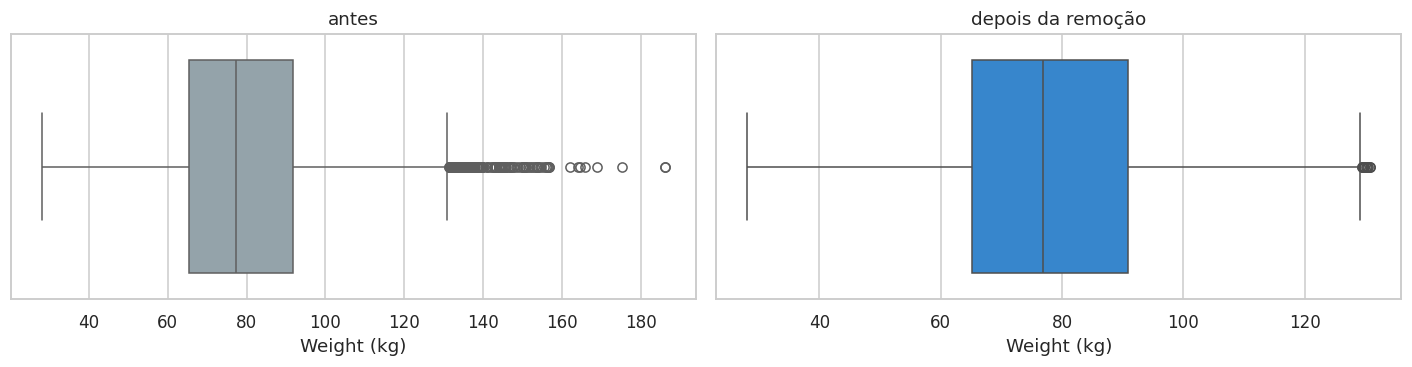

In [42]:
plt.figure(figsize=(13, 3.5))
plt.subplot(1, 2, 1)
sns.boxplot(x=df_limpo["Weight (kg)"], color="#90a4ae"); plt.title("antes")
plt.subplot(1, 2, 2)
sns.boxplot(x=df_removido["Weight (kg)"], color="#1e88e5"); plt.title("depois da remoção")
plt.tight_layout(); plt.show()

**⚠️ Observação importante (estava no notebook original e vale repetir):** depois de
remover, se você plotar o boxplot de novo, **ainda aparecem outliers**. Não é bug.
Removidos os extremos, Q1 e Q3 mudam, o IQR encolhe e as hastes se aproximam — então
valores que antes estavam dentro passam a ficar fora.

Consequência prática: **nunca repita a remoção em loop até "não sobrar outlier"**.
É um processo que só para quando você destruiu a cauda inteira da distribuição.
Vamos ver isso acontecendo:

In [43]:
temporario = df_limpo.copy()
historico = []

for rodada in range(1, 6):
    q1_t = temporario["Weight (kg)"].quantile(0.25)
    q3_t = temporario["Weight (kg)"].quantile(0.75)
    iqr_t = q3_t - q1_t
    lo_t, hi_t = q1_t - 1.5 * iqr_t, q3_t + 1.5 * iqr_t
    m_t = (temporario["Weight (kg)"] < lo_t) | (temporario["Weight (kg)"] > hi_t)

    historico.append({"rodada": rodada, "n_linhas_no_início": len(temporario),
                      "limite_sup": round(hi_t, 1), "outliers_encontrados": int(m_t.sum())})
    temporario = temporario[~m_t]

print(f"removidos na 1ª rodada: {historico[0]['outliers_encontrados']}")
print(f"removidos no total após 5 rodadas: {len(df_limpo) - len(temporario)}")
pd.DataFrame(historico)

removidos na 1ª rodada: 142
removidos no total após 5 rodadas: 156


,rodada,n_linhas_no_início,limite_sup,outliers_encontrados
0,1,8376,131.2,142
1,2,8234,129.2,11
2,3,8223,129.0,3
3,4,8220,129.0,0
4,5,8220,129.0,0


A cada rodada o limite superior **desce** e novos "outliers" aparecem — não porque
os dados mudaram, mas porque Q1 e Q3 foram recalculados sobre uma amostra já podada.
O processo até para, mas só depois de comer a cauda: removeu bem mais linhas que a
rodada inicial identificara.

**Rode a detecção uma vez só.** Se você iterar até "não sobrar outlier", o critério
de parada deixou de ser estatístico e virou "até o gráfico ficar bonito".

## 10.3 Limitar (capping / winsorização)

Em vez de excluir a linha, substitui o valor extremo pelo limite mais próximo.
Mantém o tamanho da base e a **ordem** dos valores (quem era o maior continua sendo
o maior), só comprime a cauda.

Duas formas de escolher o limite:

- pelos **limites do método** (IQR ou Z-score) — usado abaixo
- por **percentis** (ex.: 1% e 99%) — é a winsorização clássica

In [44]:
df_capping = df_limpo.copy()
df_capping["Weight (kg)"] = df_capping["Weight (kg)"].clip(lower=minimo, upper=maximo)

print(f"valores capados no limite inferior: {(df_limpo['Weight (kg)'] < minimo).sum()}")
print(f"valores capados no limite superior: {(df_limpo['Weight (kg)'] > maximo).sum()}")

antes_e_depois(peso_original, df_capping["Weight (kg)"], "capping (IQR)")

valores capados no limite inferior: 0
valores capados no limite superior: 142


capping (IQR),antes,depois,variação %
n,8376.000,8376.000,0.00
média,79.720,79.535,-0.23
mediana,77.400,77.400,0.00
desvio,20.013,19.430,-2.91
skew,0.718,0.516,-28.19
mínimo,28.100,28.100,0.00
máximo,186.200,131.150,-29.56


In [45]:
# variante por percentil — winsorização clássica
p01 = df_limpo["Weight (kg)"].quantile(0.01)
p99 = df_limpo["Weight (kg)"].quantile(0.99)

df_winsor = df_limpo.copy()
df_winsor["Weight (kg)"] = df_winsor["Weight (kg)"].clip(lower=p01, upper=p99)

print(f"percentil 1% = {p01:.2f} kg | percentil 99% = {p99:.2f} kg")
print("(por construção, isto afeta exatamente 1% de cada lado)")

antes_e_depois(peso_original, df_winsor["Weight (kg)"], "winsorização (1% / 99%)")

percentil 1% = 43.88 kg | percentil 99% = 137.03 kg
(por construção, isto afeta exatamente 1% de cada lado)


winsorização (1% / 99%),antes,depois,variação %
n,8376.000,8376.000,0.00
média,79.720,79.650,-0.09
mediana,77.400,77.400,0.00
desvio,20.013,19.566,-2.23
skew,0.718,0.602,-16.18
mínimo,28.100,43.875,56.14
máximo,186.200,137.025,-26.41


## 10.4 Imputar — cuidado, é a opção mais destrutiva

Substituir o outlier pela média ou mediana da coluna. O notebook original apresentava
isso como só mais um item da lista. Vamos ver o que ela realmente faz.

In [46]:
mediana_peso = df_limpo.loc[~mascara_out, "Weight (kg)"].median()

df_imputado = df_limpo.copy()
df_imputado.loc[mascara_out, "Weight (kg)"] = mediana_peso

print(f"mediana usada na substituição: {mediana_peso:.2f} kg")
antes_e_depois(peso_original, df_imputado["Weight (kg)"], "imputação pela mediana")

mediana usada na substituição: 76.90 kg


imputação pela mediana,antes,depois,variação %
n,8376.000,8376.000,0.00
média,79.720,78.615,-1.39
mediana,77.400,76.900,-0.65
desvio,20.013,18.211,-9.00
skew,0.718,0.392,-45.43
mínimo,28.100,28.100,0.00
máximo,186.200,130.800,-29.75


### O primeiro estrago: um pico artificial

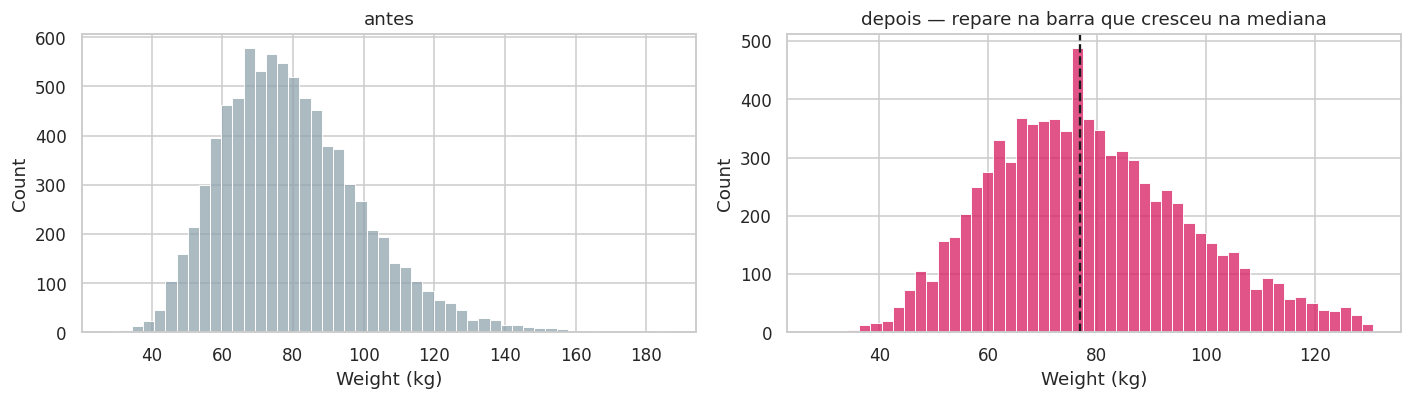

In [47]:
plt.figure(figsize=(13, 3.8))
plt.subplot(1, 2, 1)
sns.histplot(df_limpo["Weight (kg)"], bins=50, color="#90a4ae"); plt.title("antes")
plt.subplot(1, 2, 2)
sns.histplot(df_imputado["Weight (kg)"], bins=50, color="#d81b60")
plt.axvline(mediana_peso, color="k", ls="--")
plt.title("depois — repare na barra que cresceu na mediana")
plt.tight_layout(); plt.show()

### O segundo estrago, mais grave: a linha fica internamente impossível

A imputação altera **uma** coluna e deixa as outras como estavam. Resultado: uma
pessoa com peso de mediana, mas com o IMC de um obeso — um registro que não pode
existir. Veja o que acontece com as correlações:

In [48]:
correlacoes = pd.DataFrame({
    "corr(peso, altura)": [
        df_limpo["Weight (kg)"].corr(df_limpo["Standing Height (cm)"]),
        df_capping["Weight (kg)"].corr(df_capping["Standing Height (cm)"]),
        df_imputado["Weight (kg)"].corr(df_imputado["Standing Height (cm)"]),
    ],
    "corr(peso, IMC)": [
        df_limpo["Weight (kg)"].corr(df_limpo["BMI(kg/m**2)"]),
        df_capping["Weight (kg)"].corr(df_capping["BMI(kg/m**2)"]),
        df_imputado["Weight (kg)"].corr(df_imputado["BMI(kg/m**2)"]),
    ],
}, index=["sem tratamento", "capping", "imputação pela mediana"]).round(4)
correlacoes

,"corr(peso, altura)","corr(peso, IMC)"
sem tratamento,0.4751,0.8787
capping,0.4778,0.8757
imputação pela mediana,0.4546,0.7992


In [49]:
print("as linhas imputadas, ao lado do IMC que ficou intacto:")
comparativo = pd.DataFrame({
    "peso_original": df_limpo.loc[mascara_out, "Weight (kg)"],
    "peso_imputado": df_imputado.loc[mascara_out, "Weight (kg)"],
    "altura": df_limpo.loc[mascara_out, "Standing Height (cm)"],
    "IMC_na_base": df_limpo.loc[mascara_out, "BMI(kg/m**2)"],
})
comparativo["IMC_implícito_agora"] = (
    comparativo["peso_imputado"] / (comparativo["altura"] / 100) ** 2).round(1)
comparativo.head(8)

as linhas imputadas, ao lado do IMC que ficou intacto:


,peso_original,peso_imputado,altura,IMC_na_base,IMC_implícito_agora
145,133.0,76.9,187.6,37.8,21.9
159,147.5,76.9,177.6,46.8,24.4
191,148.7,76.9,189.7,41.3,21.4
208,132.5,76.9,166.4,47.9,27.8
253,186.1,76.9,185.4,54.1,22.4
266,150.0,76.9,173.4,49.9,25.6
337,144.4,76.9,173.1,48.2,25.7
361,133.7,76.9,189.0,37.4,21.5


A coluna `IMC_na_base` diz obesidade grave; o `IMC_implícito_agora` diz peso normal.
A mesma linha afirma as duas coisas.

**Se precisar imputar**, prefira uma imputação **condicional** — a mediana do grupo
ao qual a linha pertence, ou um valor previsto por modelo a partir das outras
colunas. E, de qualquer forma, marque a linha com uma flag (seção 10.1).

## 10.5 Transformar

Diferente de todas as anteriores: **nenhuma linha é removida e nenhum valor é
substituído**. Muda-se a escala, e com isso os pontos extremos deixam de ser
extremos — a cauda longa é comprimida.

| Transformação | Fórmula | Restrição |
|---|---|---|
| Logarítmica | `log(x)` ou `log1p(x)` | exige x > 0 (`log1p` aceita x = 0) |
| Raiz quadrada | `sqrt(x)` | exige x ≥ 0; efeito mais suave que o log |
| Recíproca | `1/x` | exige x ≠ 0; inverte a ordem dos valores |
| Box-Cox | `(x^λ - 1)/λ`, λ estimado | exige x > 0 |
| Yeo-Johnson | generalização do Box-Cox | aceita x ≤ 0 |

**O que o notebook original não fez: conferir se funcionou.** Aplicar `np.log` e
seguir em frente não é tratamento, é torcida. A medida de sucesso é o skew.

In [50]:
peso = df_limpo["Weight (kg)"]

transformacoes = {
    "original": peso,
    "log(x)": np.log(peso),
    "sqrt(x)": np.sqrt(peso),
    "1/x": 1 / peso,
}

# Box-Cox estima o expoente ideal automaticamente
peso_boxcox, lambda_bc = stats.boxcox(peso)
transformacoes[f"Box-Cox (λ={lambda_bc:.2f})"] = pd.Series(peso_boxcox, index=peso.index)

resultado_transf = []
for nome_t, valores in transformacoes.items():
    q1_t, q3_t = valores.quantile(0.25), valores.quantile(0.75)
    iqr_t = q3_t - q1_t
    n_out = ((valores < q1_t - 1.5 * iqr_t) | (valores > q3_t + 1.5 * iqr_t)).sum()
    resultado_transf.append({"transformação": nome_t, "skew": round(valores.skew(), 3),
                             "|skew|": round(abs(valores.skew()), 3),
                             "outliers_IQR": int(n_out)})

pd.DataFrame(resultado_transf).sort_values("|skew|").set_index("transformação")

,skew,|skew|,outliers_IQR
transformação,,,
Box-Cox (λ=0.02),-0.000,0.000,54
log(x),-0.018,0.018,54
sqrt(x),0.345,0.345,71
original,0.718,0.718,142
1/x,0.790,0.790,133


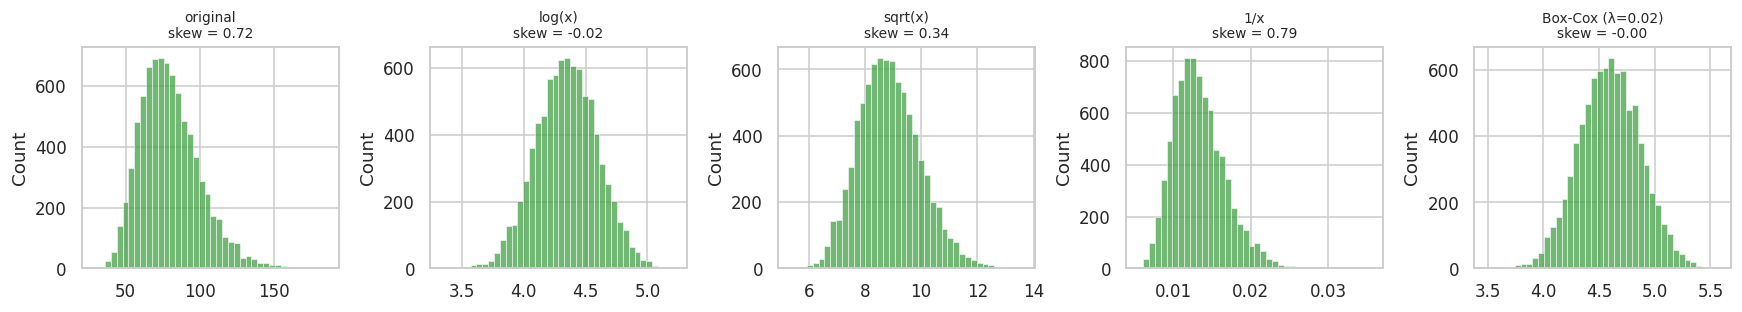

In [51]:
fig, eixos = plt.subplots(1, len(transformacoes), figsize=(3.2 * len(transformacoes), 3))
for eixo, (nome_t, valores) in zip(eixos, transformacoes.items()):
    sns.histplot(valores, bins=40, ax=eixo, color="#43a047")
    eixo.set_title(f"{nome_t}\nskew = {valores.skew():.2f}", fontsize=9)
    eixo.set_xlabel("")
plt.tight_layout()
plt.show()

A tabela está ordenada por `|skew|`: a melhor transformação é a primeira linha.
Note também a coluna `outliers_IQR` — o número de pontos extremos cai bastante
**sem que nenhum dado tenha sido descartado**. Em muitos casos é a intervenção mais
honesta disponível.

**Três avisos antes de sair transformando tudo:**

1. `log(0)` = -infinito e `log(negativo)` = NaN. Use `np.log1p` (que calcula
   `log(1+x)`) ou Yeo-Johnson quando houver zeros ou negativos.
2. A **interpretação muda**: num modelo com alvo em log, o coeficiente vira efeito
   multiplicativo (%), não aditivo. Se alguém vai ler esse coeficiente, avise.
3. Para reportar em unidade de negócio você precisa da inversa (`np.exp`), e a média
   na escala log **não** volta como a média na escala original.

## 10.6 As cinco estratégias, lado a lado

Mesma coluna, mesmos outliers, cinco tratamentos:

In [52]:
resumo_final = pd.DataFrame([
    {"estratégia": "1. sinalizar (flag)", "n_linhas": len(df_flag),
     "média": df_flag["Weight (kg)"].mean(), "desvio": df_flag["Weight (kg)"].std(),
     "skew": df_flag["Weight (kg)"].skew(),
     "corr_c/_IMC": df_flag["Weight (kg)"].corr(df_flag["BMI(kg/m**2)"])},
    {"estratégia": "2. remover", "n_linhas": len(df_removido),
     "média": df_removido["Weight (kg)"].mean(), "desvio": df_removido["Weight (kg)"].std(),
     "skew": df_removido["Weight (kg)"].skew(),
     "corr_c/_IMC": df_removido["Weight (kg)"].corr(df_removido["BMI(kg/m**2)"])},
    {"estratégia": "3. capping (IQR)", "n_linhas": len(df_capping),
     "média": df_capping["Weight (kg)"].mean(), "desvio": df_capping["Weight (kg)"].std(),
     "skew": df_capping["Weight (kg)"].skew(),
     "corr_c/_IMC": df_capping["Weight (kg)"].corr(df_capping["BMI(kg/m**2)"])},
    {"estratégia": "4. imputar mediana", "n_linhas": len(df_imputado),
     "média": df_imputado["Weight (kg)"].mean(), "desvio": df_imputado["Weight (kg)"].std(),
     "skew": df_imputado["Weight (kg)"].skew(),
     "corr_c/_IMC": df_imputado["Weight (kg)"].corr(df_imputado["BMI(kg/m**2)"])},
    {"estratégia": "5. transformar (log)", "n_linhas": len(df_limpo),
     "média": np.log(peso).mean(), "desvio": np.log(peso).std(),
     "skew": np.log(peso).skew(),
     "corr_c/_IMC": np.log(peso).corr(df_limpo["BMI(kg/m**2)"])},
]).set_index("estratégia").round(4)
resumo_final

,n_linhas,média,desvio,skew,corr_c/_IMC
estratégia,,,,,
1. sinalizar (flag),8376,79.7199,20.0125,0.7182,0.8787
2. remover,8234,78.6445,18.3657,0.3838,0.8634
3. capping (IQR),8376,79.5346,19.4301,0.5157,0.8757
4. imputar mediana,8376,78.6149,18.2107,0.3919,0.7992
5. transformar (log),8376,4.3478,0.2480,-0.0183,0.8698


Como escolher (a linha 5 está em outra escala, então compare só o skew e a correlação):

| Se... | Use |
|---|---|
| você não sabe ainda / quer auditar depois | **sinalizar** |
| é erro comprovado (seção 9) | **remover** |
| é valor real, mas você quer limitar a influência | **capping** |
| a distribuição é assimétrica e vai entrar num modelo linear | **transformar** |
| ...quase nunca | imputar |

---
## 11. E quando isso entra num modelo? O vazamento de dados

O título do notebook original mencionava Machine Learning, então vale fechar com o
erro mais caro nesse contexto — e ele não tem nada a ver com qual método você escolheu.

Todos os limiares que calculamos (média, desvio, Q1, Q3, percentis) são **parâmetros
estimados a partir dos dados**. Se você os calcula sobre a base inteira e depois
separa treino e teste, o limiar aplicado ao treino carrega informação das linhas de
teste. Isso é **data leakage**: sua métrica fica otimista e o modelo decepciona em produção.

O correto: calcular limiares **só no treino** e aplicá-los ao teste.

In [53]:
from sklearn.model_selection import train_test_split

treino, teste = train_test_split(df_limpo, test_size=0.25, random_state=SEED)

# ERRADO — limites calculados na base inteira
q1_errado = df_limpo["Weight (kg)"].quantile(0.25)
q3_errado = df_limpo["Weight (kg)"].quantile(0.75)
limite_errado = q3_errado + 1.5 * (q3_errado - q1_errado)

# CERTO — limites calculados só no treino
q1_certo = treino["Weight (kg)"].quantile(0.25)
q3_certo = treino["Weight (kg)"].quantile(0.75)
limite_certo = q3_certo + 1.5 * (q3_certo - q1_certo)

print(f"limite superior calculado na base inteira (errado): {limite_errado:.2f} kg")
print(f"limite superior calculado só no treino  (correto): {limite_certo:.2f} kg")
print(f"diferença: {abs(limite_certo - limite_errado):.2f} kg")

limite superior calculado na base inteira (errado): 131.15 kg
limite superior calculado só no treino  (correto): 130.99 kg
diferença: 0.16 kg


Com 8 mil linhas a diferença é pequena. O problema é que ela **cresce quando a base
é pequena** — exatamente quando você mais precisa de uma métrica confiável:

In [54]:
resultado_vazamento = []

for tamanho in [100, 300, 1000, 3000, len(df_limpo)]:
    diferencas = []
    for repeticao in range(30):
        amostra = df_limpo.sample(min(tamanho, len(df_limpo)), random_state=repeticao)
        tr, _ = train_test_split(amostra, test_size=0.25, random_state=repeticao)

        qa1, qa3 = amostra["Weight (kg)"].quantile([0.25, 0.75])
        qt1, qt3 = tr["Weight (kg)"].quantile([0.25, 0.75])
        lim_a = qa3 + 1.5 * (qa3 - qa1)
        lim_t = qt3 + 1.5 * (qt3 - qt1)
        diferencas.append(abs(lim_t - lim_a))

    resultado_vazamento.append({"n": len(amostra),
                                "diferença média no limiar (kg)": round(np.mean(diferencas), 3)})

pd.DataFrame(resultado_vazamento).set_index("n")

,diferença média no limiar (kg)
n,
100,2.832
300,2.327
1000,1.198
3000,0.702
8376,0.337


**Na prática**, isso se resolve encapsulando o tratamento num transformer do sklearn
e colocando dentro de um `Pipeline` — assim o `fit` acontece só no treino,
automaticamente, inclusive dentro da validação cruzada:

```python
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

class LimitadorIQR(BaseEstimator, TransformerMixin):
    def __init__(self, k=1.5):
        self.k = k

    def fit(self, X, y=None):                  # aprende SÓ com o treino
        X = pd.DataFrame(X)
        q1, q3 = X.quantile(0.25), X.quantile(0.75)
        self.inferior_ = q1 - self.k * (q3 - q1)
        self.superior_ = q3 + self.k * (q3 - q1)
        return self

    def transform(self, X):                    # aplica no treino E no teste
        return pd.DataFrame(X).clip(self.inferior_, self.superior_, axis=1).to_numpy()

modelo = Pipeline([("limitador", LimitadorIQR(k=1.5)),
                   ("regressao", LinearRegression())])
```

Bônus: com o `k` como parâmetro do transformer, ele vira um **hiperparâmetro
buscável** por `GridSearchCV` — em vez de um número chutado no meio do código.

**Última regra:** você pode remover outliers do **treino**; nunca do **teste**.
O conjunto de teste precisa refletir os dados que vão chegar em produção, extremos
inclusive. Um teste "limpo" produz uma métrica que descreve um mundo que não existe.

---
## 12. Resumo — a colinha

**Detectar**

| Método | Quando | Cuidado |
|---|---|---|
| Boxplot / histograma / scatter | sempre, primeiro | scatter revela o outlier bivariado |
| Z-score (\|z\| > 3) | distribuição simétrica | mascaramento (7.2.1) |
| Z-score modificado / MAD (> 3,5) | qualquer caso, principalmente amostra pequena | menos conhecido, não menos correto |
| IQR (1,5 × IQR) | distribuição assimétrica | `k` é escolha sua |
| Isolation Forest / LOF / DBSCAN | várias colunas, outlier bivariado | padronizar antes; `contamination` é premissa |

**Tratar**

| Estratégia | Perde linha? | Altera valor? | Quando |
|---|---|---|---|
| Sinalizar | não | não | padrão — comece aqui |
| Remover | sim | — | erro comprovado |
| Capping | não | sim (só extremos) | valor real, influência a limitar |
| Imputar | não | sim | quase nunca |
| Transformar | não | todos (escala) | assimetria + modelo linear |

**Os sete hábitos que evitam a maioria dos erros**

1. Cheque nulos antes — `NaN` escapa de qualquer filtro por comparação
2. Olhe o gráfico antes de escolher o método; olhe o skew para confirmar
3. Sempre imprima **quantos** e **qual %** foram marcados (>5% = método errado)
4. **Investigue** antes de tratar: impossível / implausível / apenas raro?
5. Trate uma vez só — nunca em loop
6. Meça o antes e o depois de todo tratamento
7. Em ML: `fit` só no treino; nunca limpe o conjunto de teste